<a href="https://colab.research.google.com/github/Thanhpham007/STROKE_PREDICTION/blob/main/STROKE_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**#1.Khai báo thư viện**

In [ ]:
!pip install scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score


**#2. Kết nối dữ liệu**

In [ ]:
#Đọc dữ liệu
df = pd.read_csv('/content/drive/MyDrive/NCKH_STROKE/healthcare-dataset-stroke-data.csv')

**#3.Mô tả bộ dữ liệu**

In [ ]:
df.shape

(5110, 12)

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.dtypes

,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


In [ ]:
#Thống kê giá trị định lượng các thuộc tính
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
#Kiểm tra giá trị có bị thiếu
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


**#4.Tiền xử lý dữ liệu**

**#xử lý bmi**

In [ ]:
# Chia thành 2 tập: có BMI và thiếu BMI
df_full = df[df['bmi'].notnull()].copy()
df_missing = df[df['bmi'].isnull()].copy()

# Chọn đặc trưng để dự đoán BMI
features = ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
'work_type', 'Residence_type', 'avg_glucose_level', 'smoking_status']

X = df_full[features]
y = df_full['bmi']

In [ ]:
# Mã hoá biến phân loại
X = X.copy()
encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le


# Chia dữ liệu thành tập train/val(80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

# Chuẩn hoá dữ liệu cho SVR, KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

# Hàm đánh giá
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n===== {model_name} =====")
    print(f"Best Params: {model_name}")
    print(f"MAE  = {mae:.4f}")
    print(f"MSE  = {mse:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")

# Pipelines
pipelines = {
    "XGBoost": Pipeline([
        ("model", xgb.XGBRegressor(random_state=42))
    ]),
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR())
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor())
    ]),
    "Linear Regression": Pipeline([
        ("model", LinearRegression())
    ])
}

# Tham số cho GridSearchCV
param_grids = {
    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.1, 0.2]
    },
    "SVR": {
        "model__kernel": ["linear", "rbf"],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9],
        "model__weights": ["uniform", "distance"]
    },
    "Linear Regression": {
        # LinearRegression không nhiều tham số, ta thêm normalize nếu muốn
        # (từ sklearn 1.2 trở đi, normalize đã deprecated)
    }
}

best_models = {}

# Train + GridSearchCV
for name, pipe in pipelines.items():
    print(f"\nĐang chạy GridSearchCV cho {name}...")
    grid = GridSearchCV(pipe, param_grids.get(name, {}),
                        cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_
    y_pred = best_models[name].predict(X_val)

    print(f"Best Params: {grid.best_params_}")
    evaluate(y_val, y_pred, name)


Đang chạy GridSearchCV cho XGBoost...
Best Params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}

===== XGBoost =====
Best Params: XGBoost
MAE  = 5.1792
MSE  = 51.0590
RMSE = 7.1456
R²   = 0.2540

Đang chạy GridSearchCV cho SVR...
Best Params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

===== SVR =====
Best Params: SVR
MAE  = 5.1033
MSE  = 53.6595
RMSE = 7.3253
R²   = 0.2160

Đang chạy GridSearchCV cho KNN...
Best Params: {'model__n_neighbors': 9, 'model__weights': 'uniform'}

===== KNN =====
Best Params: KNN
MAE  = 5.5195
MSE  = 55.5491
RMSE = 7.4531
R²   = 0.1884

Đang chạy GridSearchCV cho Linear Regression...
Best Params: {}

===== Linear Regression =====
Best Params: Linear Regression
MAE  = 5.5193
MSE  = 57.3061
RMSE = 7.5701
R²   = 0.1627


In [ ]:
#1.Lấy mô hình XGBoost tốt nhất từ GridSearchCV
best_xgb = best_models["XGBoost"]

#2.Chuẩn bị dữ liệu thiếu BMI
X_missing = df_missing[features].copy()

# Mã hoá biến
for col, le in encoders.items():
    X_missing[col] = le.transform(X_missing[col])

#3.Dự đoán giá trị BMI bị thiếu
bmi_pred_missing = best_xgb.predict(X_missing)

#4.Gán lại vào df_missing
df_missing['bmi'] = bmi_pred_missing

#5.Hợp nhất lại 2 tập
df_completed = pd.concat([df_full, df_missing]).sort_index()

print("Số dòng còn thiếu BMI sau khi dự đoán bằng XGBoost:", df_completed['bmi'].isnull().sum())

Số dòng còn thiếu BMI sau khi dự đoán bằng XGBoost: 0


**#Khám phá dữ liệu**

In [ ]:
# select numerical features
features_cat = ['age', 'avg_glucose_level','bmi']

In [ ]:
# basic stats
df[features_cat].describe(percentiles=[0.1,0.25,0.5,0.75,0.9])

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
10%,11.000000,65.789000,19.700000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
90%,75.000000,192.181000,38.900000
max,82.000000,271.740000,97.600000


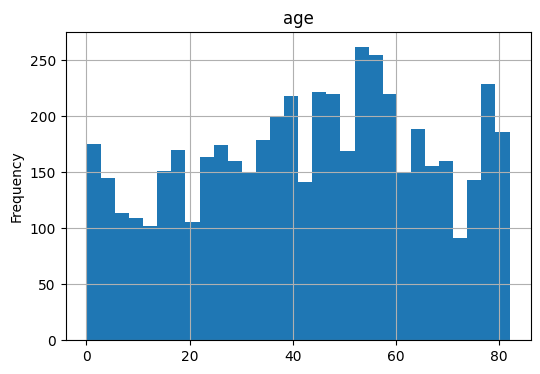

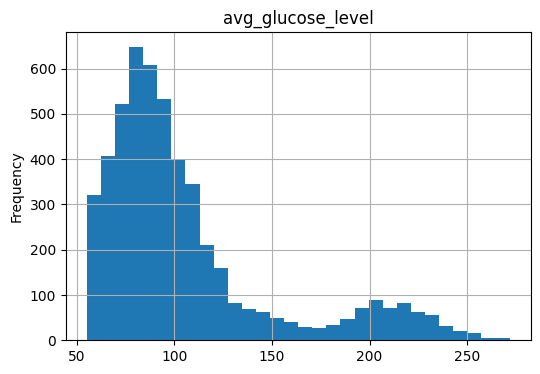

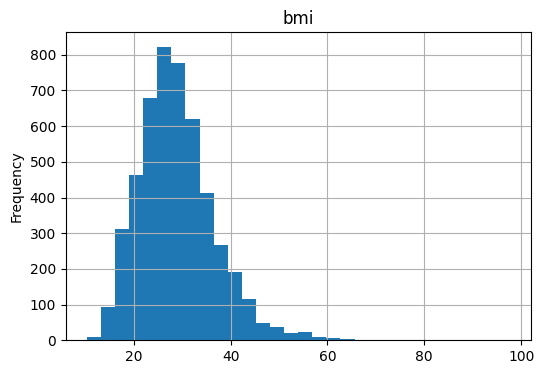

<Figure size 640x480 with 0 Axes>

In [ ]:
cols = features_cat



for f in cols:
    plt.figure(figsize=(6,4))  # tạo hình riêng
    df[f].plot(kind='hist', bins=30)
    plt.title(f)
    plt.grid(True)
    plt.show()

plt.tight_layout()
plt.show()


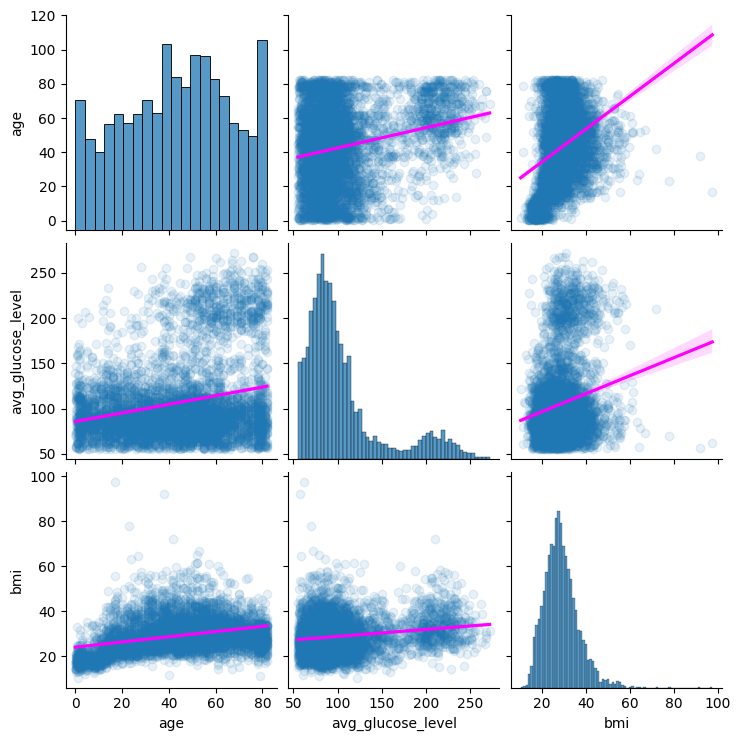

In [ ]:
# pairwise scatter plot
sns.pairplot(df[features_cat],
             kind='reg',
             plot_kws={'line_kws':{'color':'magenta'}, 'scatter_kws': {'alpha': 0.1}})
plt.show()

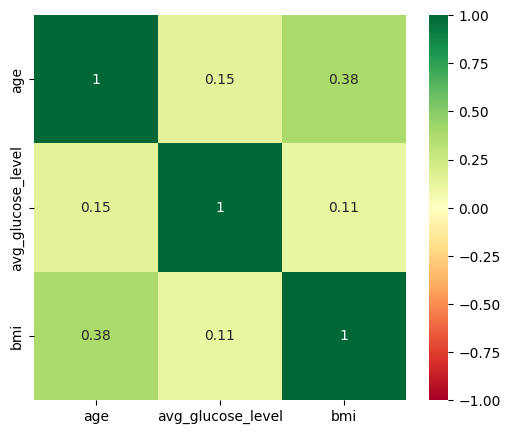

In [ ]:
# Tương quan đặc trưng
corr_spearman = df[features_cat].corr(method='spearman')

fig = plt.figure(figsize = (6,5))
sns.heatmap(corr_spearman, annot=True, cmap="RdYlGn", vmin=-1, vmax=+1)
#plt.title('Biểu đồ tương quan đặc trưng')
plt.show()

-------------------------------------------------------------------------------

In [ ]:
features_cat = ['gender','hypertension','heart_disease','ever_married',
                'work_type','Residence_type','smoking_status']

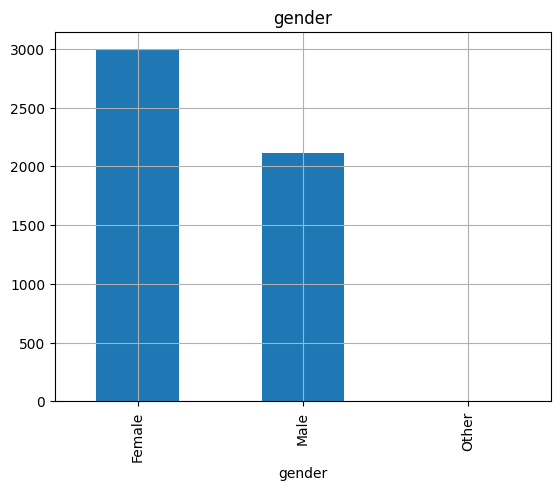

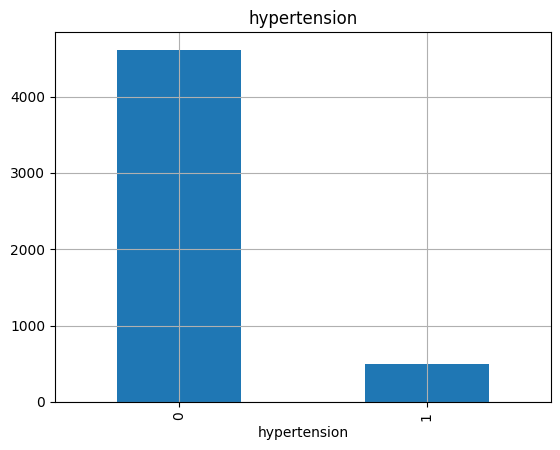

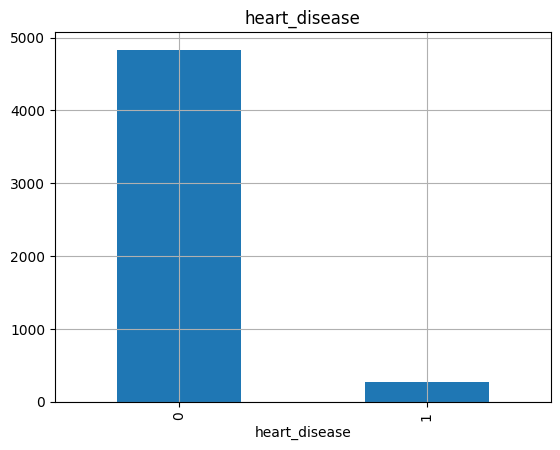

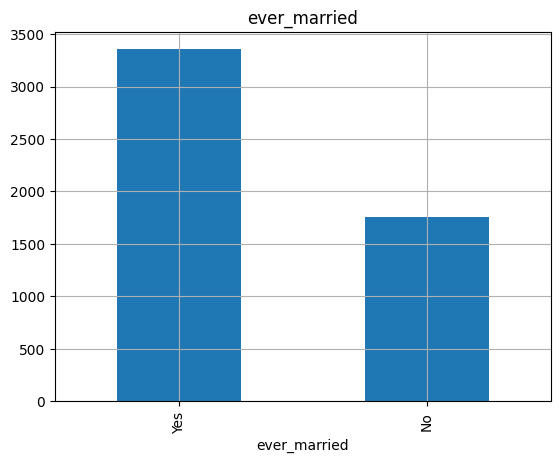

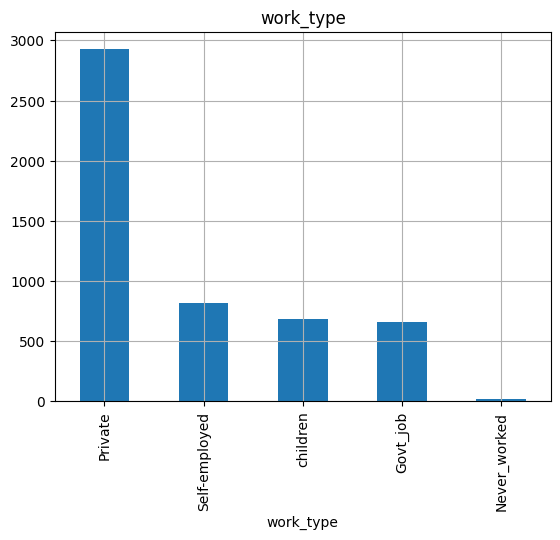

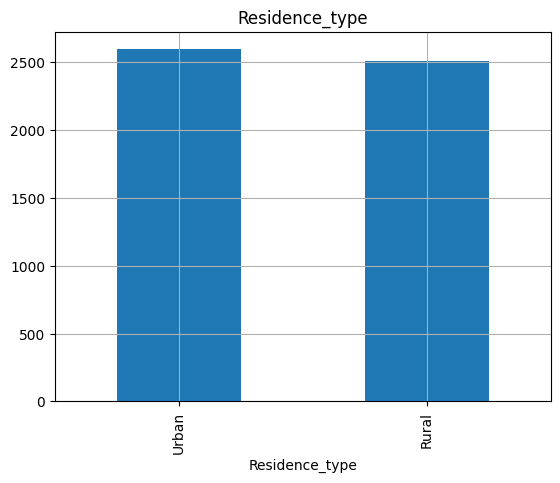

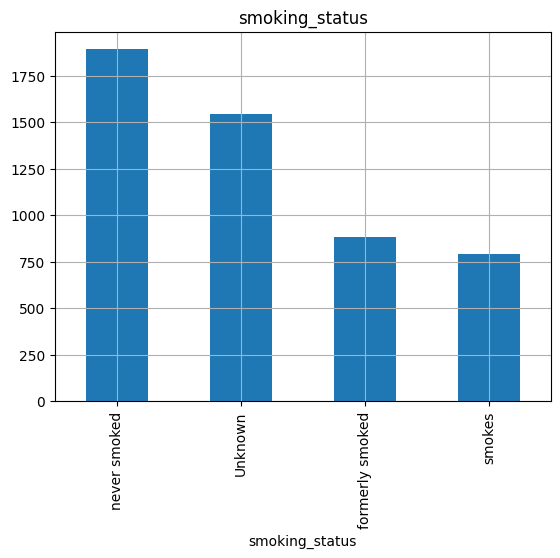

In [ ]:
# plot distribution of categorical features
for f in features_cat:
    df[f].value_counts().plot(kind='bar')
    plt.title(f)
    plt.grid()
    plt.show()

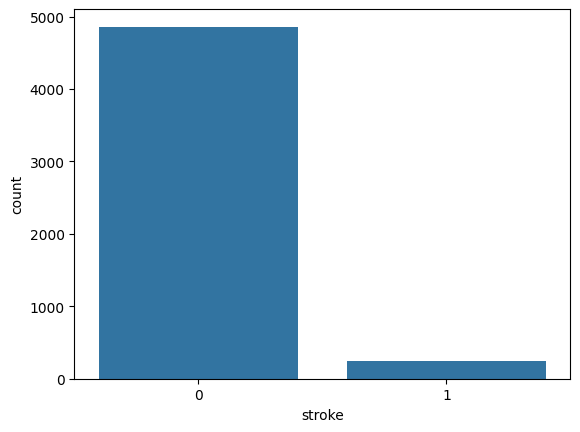

In [ ]:
sns.countplot(x='stroke', data=df)
#plt.title('Phân bố của biến Đột quỵ')
plt.show()

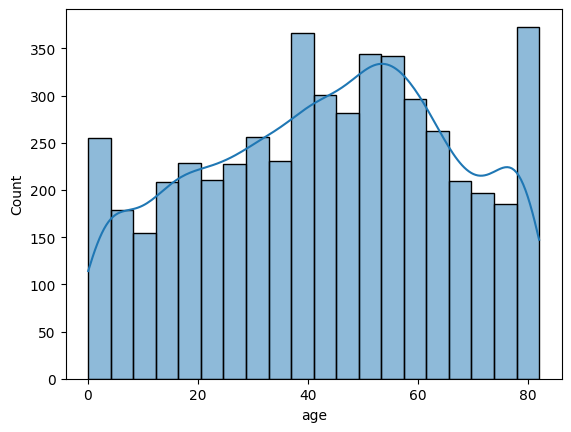

In [ ]:
sns.histplot(df['age'], kde=True)
#plt.title(f'Phân bố của người mắc bệnh theo độ tuổi')
plt.show()


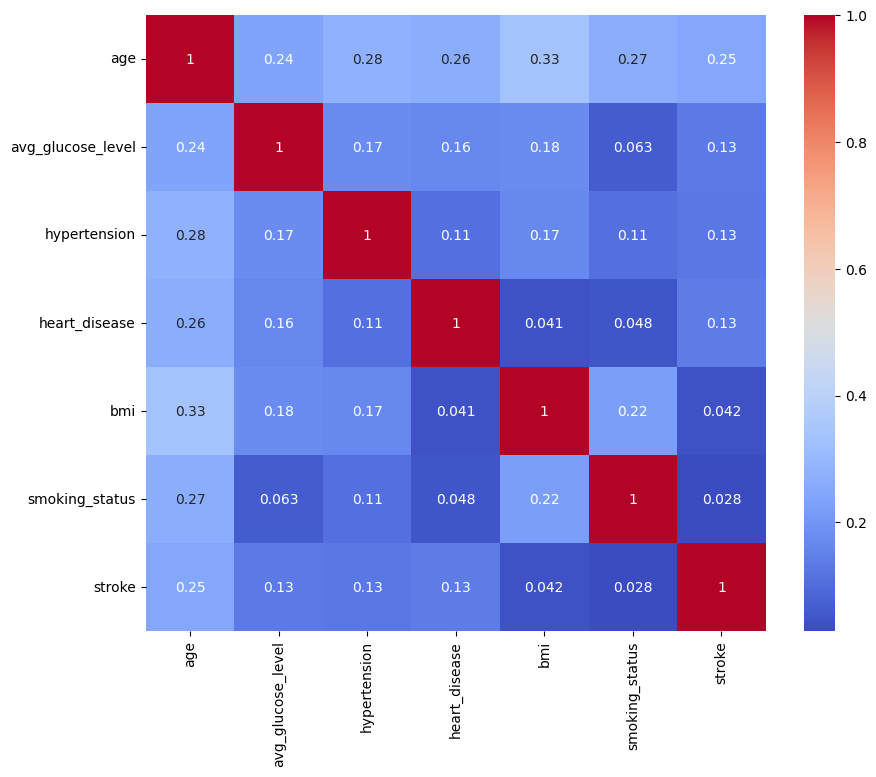

In [ ]:
numerical_cols = ['age', 'avg_glucose_level', 'hypertension', 'heart_disease', 'bmi', 'smoking_status', 'stroke']
df['smoking_status'] = df['smoking_status'].astype('category').cat.codes

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
#plt.title('Biểu đồ tương quan giữa các đặc trưng')
plt.show()

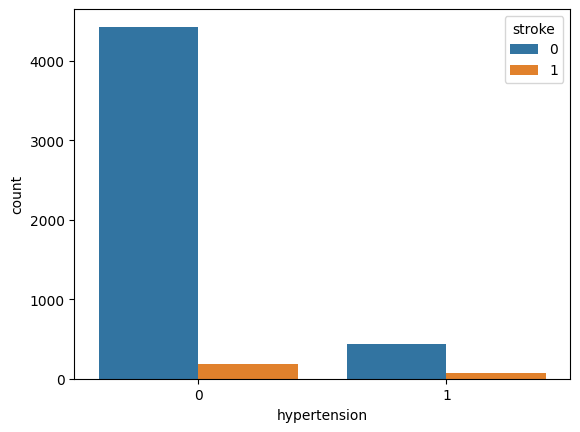

In [ ]:
sns.countplot(x='hypertension', hue='stroke', data=df)
#plt.title('Phân bố của Huyết áp theo Đột quỵ')
plt.show()

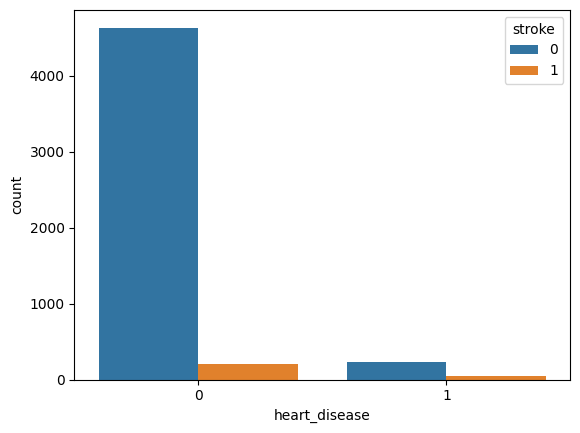

In [ ]:
sns.countplot(x='heart_disease', hue='stroke', data=df)
#plt.title('Phân bố của Bệnh tim theo Đột quỵ')
plt.show()

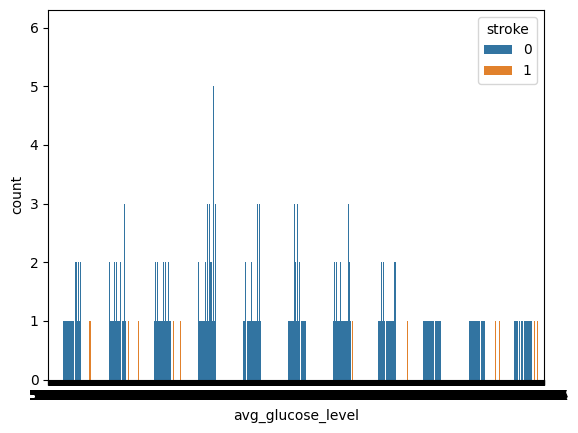

In [ ]:
sns.countplot(x='avg_glucose_level', hue='stroke', data=df)
#plt.title('Phân bố của Mức đường huyết theo Đột quỵ')
plt.show()

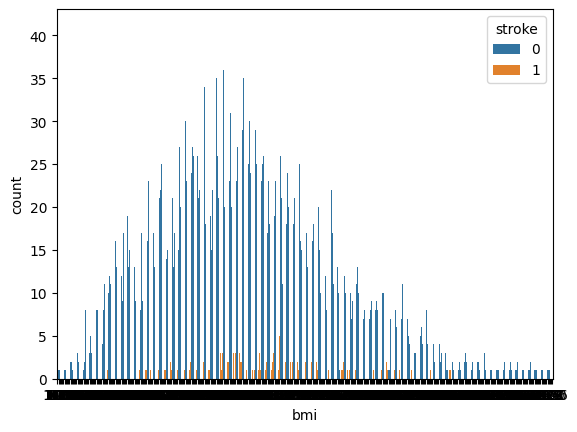

In [ ]:
sns.countplot(x='bmi', hue='stroke', data=df)
#plt.title('Phân bố của Chỉ số khối sức khỏe theo Đột quỵ')
plt.show()

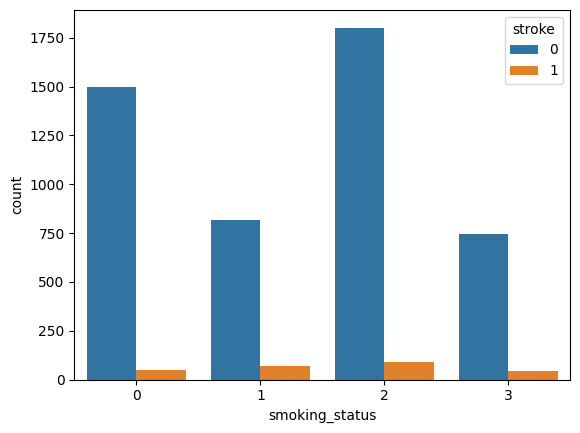

In [ ]:
sns.countplot(x='smoking_status', hue='stroke', data=df)
#plt.title('Phân bố của Tình trạng hút thuốc theo Đột quỵ')
plt.show()

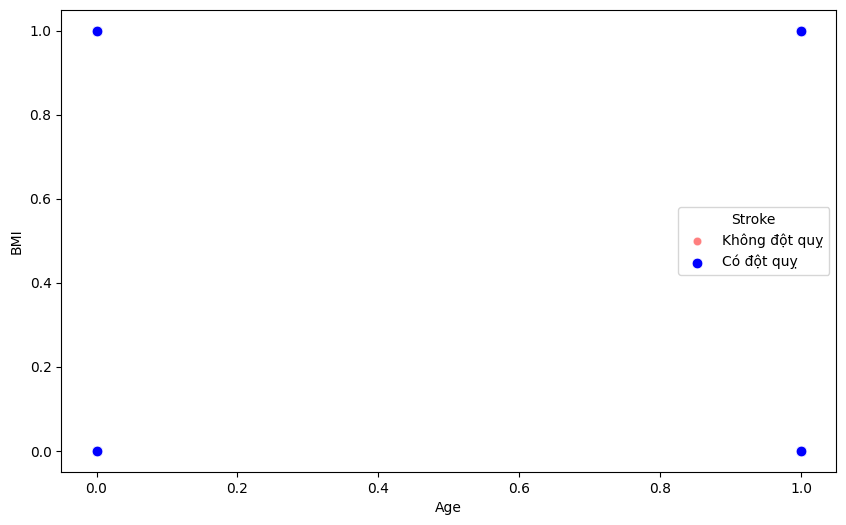

In [ ]:
plt.figure(figsize=(10,6))

# Vẽ những người không đột quỵ
sns.scatterplot(
    data=df[df['stroke']==0],
    x='hypertension',
    y='heart_disease',
    color='red',
    label='Không đột quỵ',
    alpha=0.5
)

# Vẽ những người bị đột quỵ
sns.scatterplot(
    data=df[df['stroke']==1],
    x='hypertension',
    y='heart_disease',
    color='blue',
    label='Có đột quỵ',
    s=60  # điểm stroke=1 to hơn cho dễ thấy
)

#plt.title('Biểu đồ phân tán giữa Huyết áp và Bệnh tim theo trạng thái Đột quỵ')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.legend(title='Stroke')
plt.show()

In [ ]:
# Đếm số lượng mỗi loại Đột quỵ
print(df['stroke'].value_counts())

stroke
0    4861
1     249
Name: count, dtype: int64


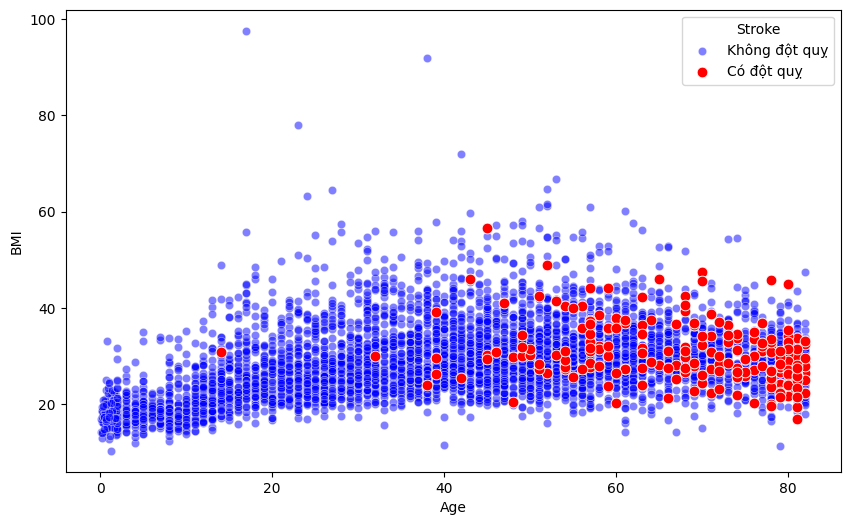

In [ ]:
plt.figure(figsize=(10,6))

# Vẽ những người không đột quỵ
sns.scatterplot(
    data=df[df['stroke']==0],
    x='age',
    y='bmi',
    color='blue',
    label='Không đột quỵ',
    alpha=0.5
)

# Vẽ những người bị đột quỵ
sns.scatterplot(
    data=df[df['stroke']==1],
    x='age',
    y='bmi',
    color='red',
    label='Có đột quỵ',
    s=60  # điểm stroke=1 to hơn cho dễ thấy
)

#plt.title('Biểu đồ phân tán giữa Độ tuổi và Chỉ số khối cơ thể theo trạng thái Đột quỵ')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.legend(title='Stroke')
plt.show()


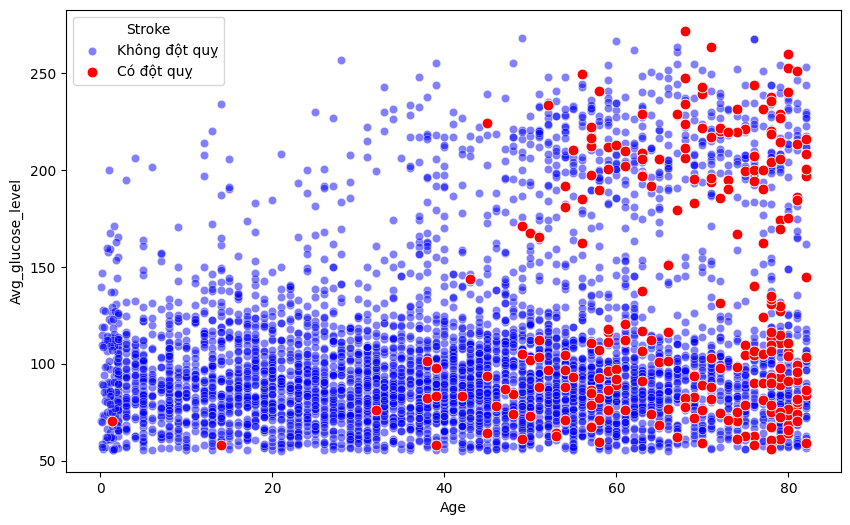

In [ ]:
plt.figure(figsize=(10,6))

# Vẽ những người không đột quỵ
sns.scatterplot(
    data=df[df['stroke']==0],
    x='age',
    y='avg_glucose_level',
    color='blue',
    label='Không đột quỵ',
    alpha=0.5
)

# Vẽ những người bị đột quỵ
sns.scatterplot(
    data=df[df['stroke']==1],
    x='age',
    y='avg_glucose_level',
    color='red',
    label='Có đột quỵ',
    s=60  # điểm stroke=1 to hơn cho dễ thấy
)

#plt.title('Biểu đồ phân tán giữa Độ tuổi và Mức đường huyết theo trạng thái Đột quỵ')
plt.xlabel('Age')
plt.ylabel('Avg_glucose_level')
plt.legend(title='Stroke')
plt.show()

**#Cân bằng dữ liệu**

In [ ]:
!pip install imbalanced-learn

Kích thước tập Train: (3577, 11)
Kích thước tập Validation: (766, 11)
Kích thước tập Test: (767, 11)
Số lượng nhãn trước SMOTE (Train):
stroke
0    3403
1     174
Name: count, dtype: int64
Số lượng nhãn sau SMOTE (Train):
stroke
0    3403
1    3403
Name: count, dtype: int64


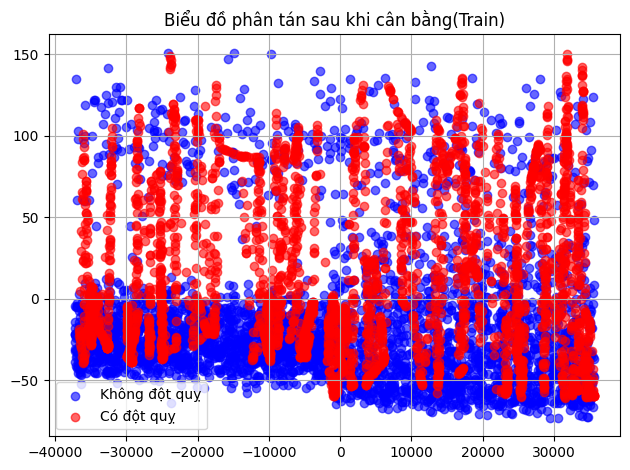

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Tách feature và label
X = df_completed.drop('stroke', axis=1)
y = df_completed['stroke']

# 2. Encode các cột phân loại
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# 3. Chia dữ liệu: Train (70%) - Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 3.1 Chia Temp thành Validation (15%) và Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Kích thước tập Train:", X_train.shape)
print("Kích thước tập Validation:", X_val.shape)
print("Kích thước tập Test:", X_test.shape)

# 4. Áp dụng SMOTE chỉ trên tập Train
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 5. Kiểm tra kết quả
print('Số lượng nhãn trước SMOTE (Train):')
print(y_train.value_counts())
print('Số lượng nhãn sau SMOTE (Train):')
print(y_train_smote.value_counts())

# 6. Trực quan hóa bằng PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_smote)

# Nhãn 0: Không đột quỵ (màu xanh)
plt.scatter(
    X_pca[y_train_smote == 0, 0],
    X_pca[y_train_smote == 0, 1],
    c='blue',
    label='Không đột quỵ',
    alpha=0.6
)
# Nhãn 1: Đột quỵ (màu đỏ)
plt.scatter(
    X_pca[y_train_smote == 1, 0],
    X_pca[y_train_smote == 1, 1],
    c='red',
    label='Có đột quỵ',
    alpha=0.6
)
plt.title("Biểu đồ phân tán sau khi cân bằng(Train)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**#Khởi tạo và đánh giá cả ba mô hình RandomForest, Logistic Regression, LightGBM**

**#CÓ SMOTE**


========== LogReg ==========
Best params: {'clf__C': 0.1, 'clf__penalty': 'l2'}

[Validation] Classification report:
               precision    recall  f1-score   support

           0     0.9793    0.7778    0.8670       729
           1     0.1337    0.6757    0.2232        37

    accuracy                         0.7728       766
   macro avg     0.5565    0.7267    0.5451       766
weighted avg     0.9384    0.7728    0.8359       766



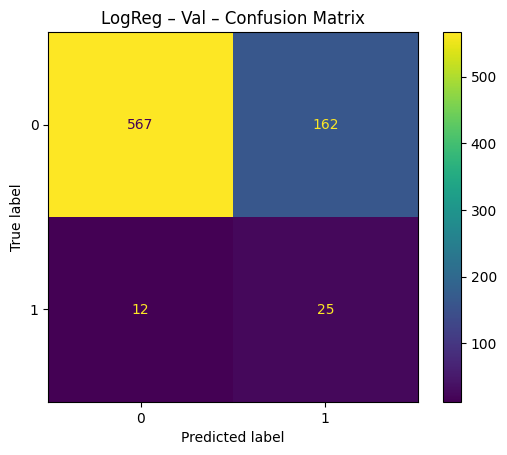

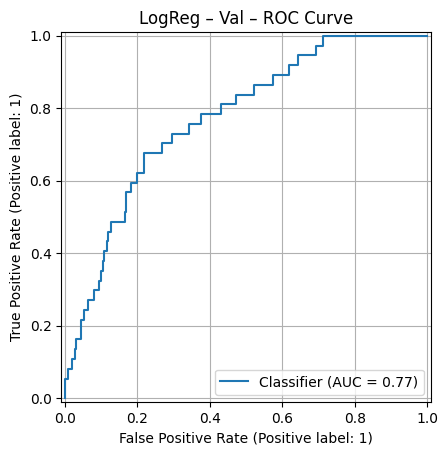

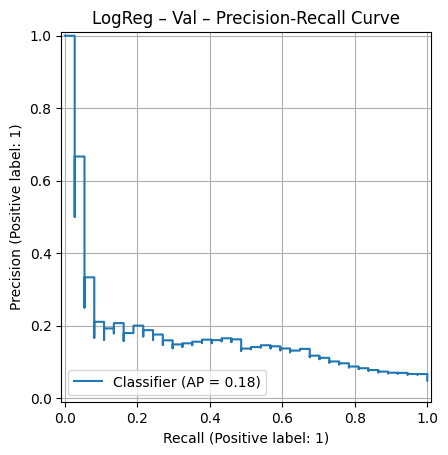


[Test] Classification report:
               precision    recall  f1-score   support

           0     0.9713    0.7901    0.8714       729
           1     0.1207    0.5526    0.1981        38

    accuracy                         0.7784       767
   macro avg     0.5460    0.6714    0.5348       767
weighted avg     0.9292    0.7784    0.8380       767



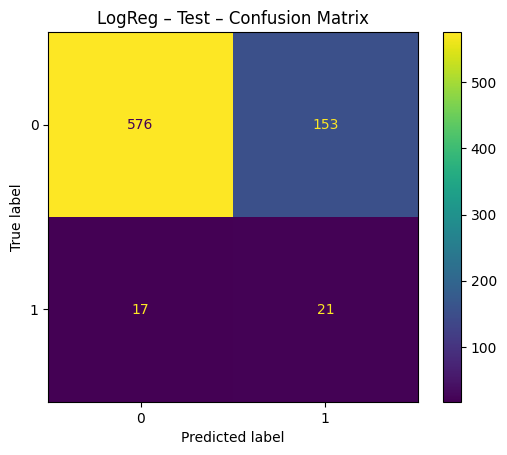

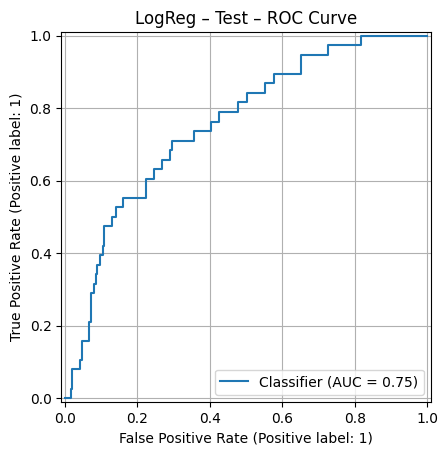

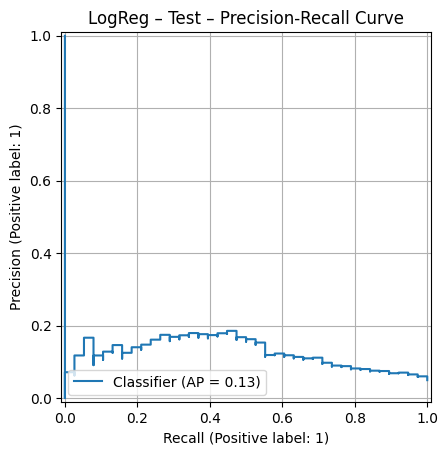


========== RandomForest ==========
Best params: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}

[Validation] Classification report:
               precision    recall  f1-score   support

           0     0.9598    0.9177    0.9383       729
           1     0.1304    0.2432    0.1698        37

    accuracy                         0.8851       766
   macro avg     0.5451    0.5805    0.5541       766
weighted avg     0.9198    0.8851    0.9012       766



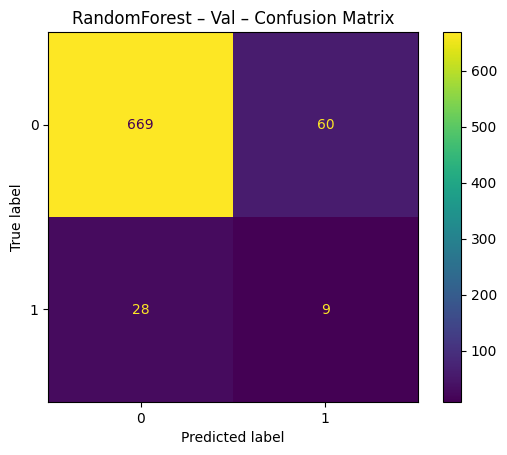

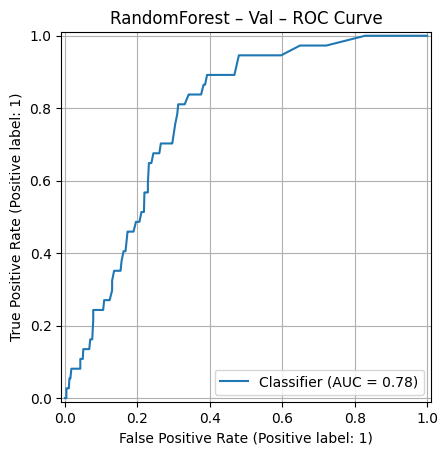

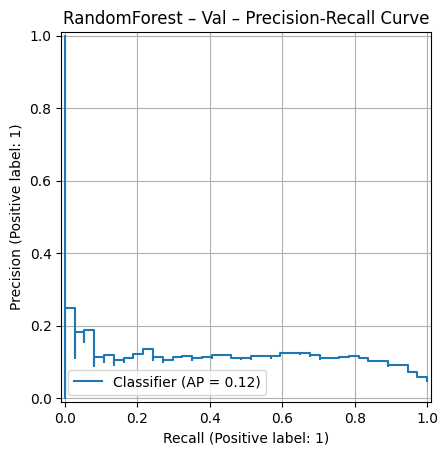


[Test] Classification report:
               precision    recall  f1-score   support

           0     0.9580    0.9081    0.9324       729
           1     0.1184    0.2368    0.1579        38

    accuracy                         0.8748       767
   macro avg     0.5382    0.5725    0.5451       767
weighted avg     0.9164    0.8748    0.8940       767



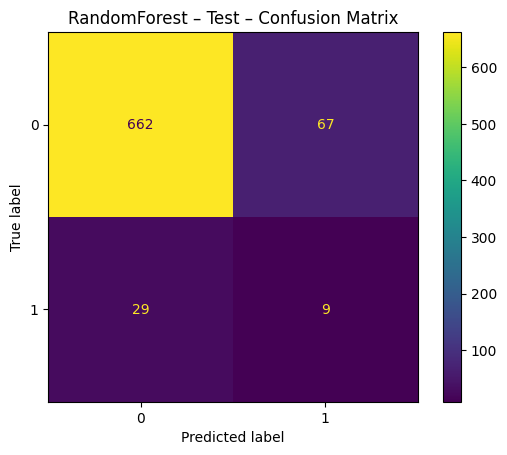

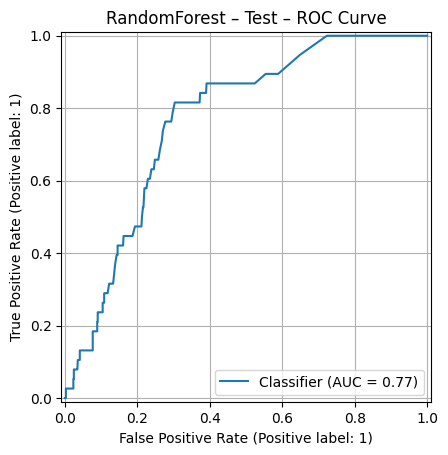

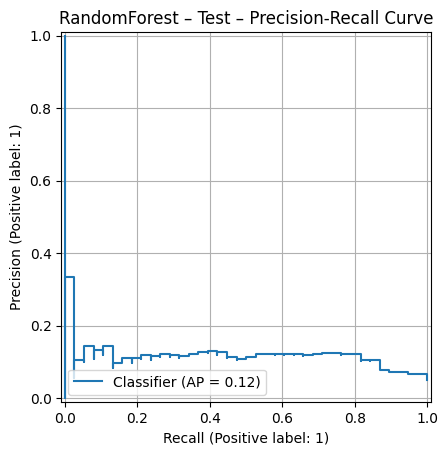


========== LightGBM ==========
[LightGBM] [Info] Number of positive: 3403, number of negative: 3403
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000807 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1040
[LightGBM] [Info] Number of data points in the train set: 6806, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best params: {'clf__learning_rate': 0.1, 'clf__n_estimators': 200, 'clf__num_leaves': 63}

[Validation] Classification report:
               precision    recall  f1-score   support

           0     0.9552    0.9643    0.9597       729
           1     0.1333    0.1081    0.1194        37

    accuracy                         0.9230       766
   macro avg     0.5442    0.5362    0.5396       766
weighted avg     0.9155    0.9230    0.9191       766



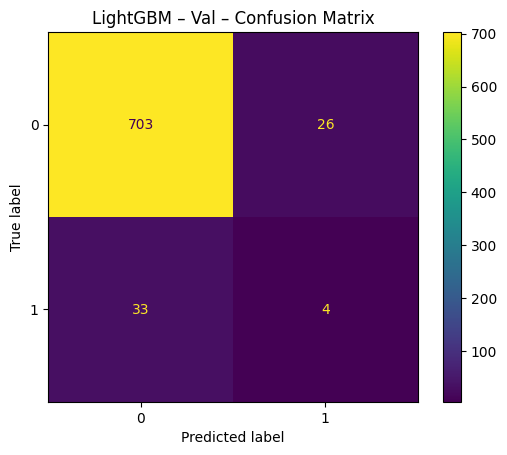

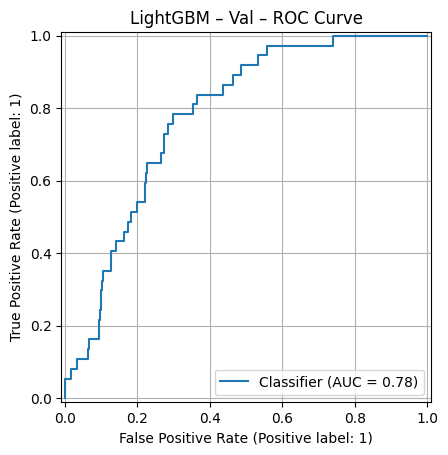

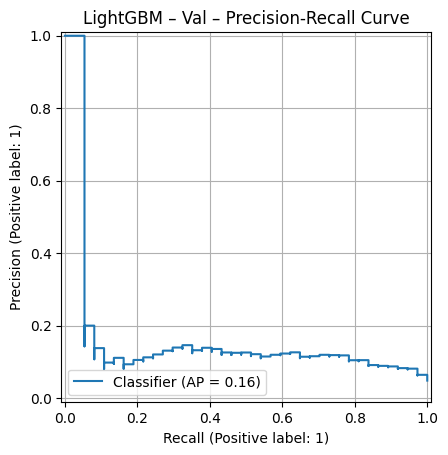


[Test] Classification report:
               precision    recall  f1-score   support

           0     0.9537    0.9602    0.9569       729
           1     0.1212    0.1053    0.1127        38

    accuracy                         0.9179       767
   macro avg     0.5374    0.5327    0.5348       767
weighted avg     0.9124    0.9179    0.9151       767



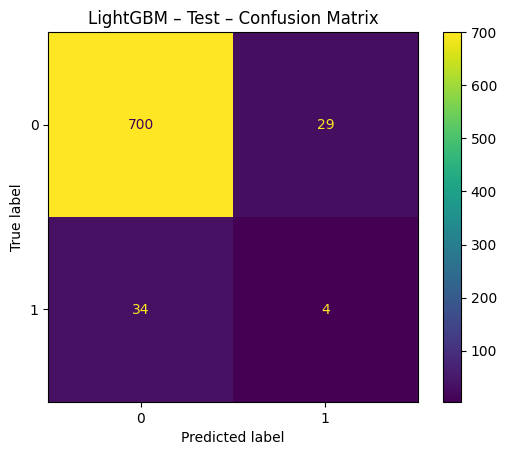

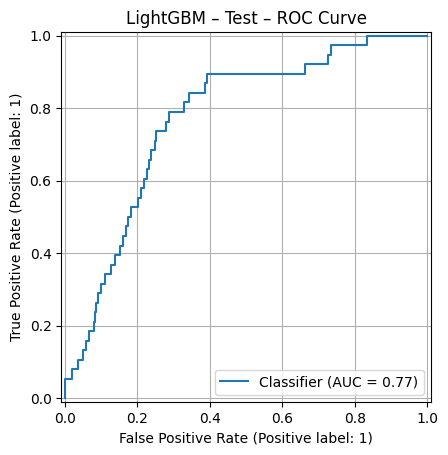

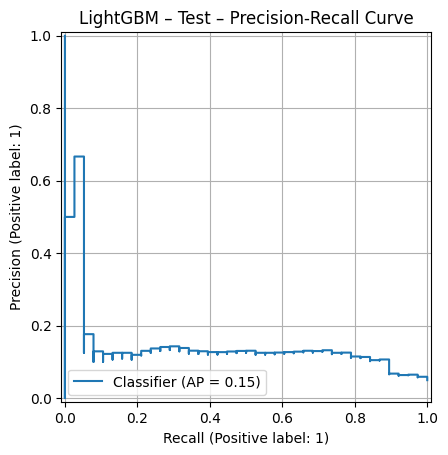

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier

#1. Utility functions
#-----------------------------

def evaluate(model, X, y, set_name: str):
    proba = model.predict_proba(X)[:, 1]
    preds = (proba >= 0.5).astype(int)
    print(f"\n[{set_name}] Classification report:\n", classification_report(y, preds, digits=4))
    return preds, proba

def plot_results(y_true, preds, proba, prefix: str):
    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_true, preds)
    plt.title(f"{prefix} – Confusion Matrix")
    plt.grid(False)
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_predictions(y_true, proba)
    plt.title(f"{prefix} – ROC Curve")
    plt.grid(True)
    plt.show()

    # Precision-Recall Curve
    PrecisionRecallDisplay.from_predictions(y_true, proba)
    plt.title(f"{prefix} – Precision-Recall Curve")
    plt.grid(True)
    plt.show()

#2. CV + parameter grids
#-----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}

# Logistic Regression
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="liblinear"))
])
param_lr = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l1", "l2"]
}

# Random Forest
pipe_rf = Pipeline([
    ("clf", RandomForestClassifier(random_state=42))
])
param_rf = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5]
}

# LightGBM
pipe_lgbm = Pipeline([
    ("clf", LGBMClassifier(random_state=42))
])
param_lgbm = {
    "clf__n_estimators": [100, 200],
    "clf__num_leaves": [31, 63],
    "clf__learning_rate": [0.05, 0.1]
}

models = {
    "LogReg": (pipe_lr, param_lr),
    "RandomForest": (pipe_rf, param_rf),
    "LightGBM": (pipe_lgbm, param_lgbm)
}

#3. Huấn luyện và đánh giá
#-----------------------------
for name, (pipe, param) in models.items():
    print("\n==========", name, "==========")
    grid = GridSearchCV(pipe, param_grid=param, cv=cv, scoring=scoring, refit="pr_auc", n_jobs=-1)
    grid.fit(X_train_smote, y_train_smote)
    print("Best params:", grid.best_params_)

    # Validation
    preds_val, proba_val = evaluate(grid, X_val, y_val, "Validation")
    plot_results(y_val, preds_val, proba_val, f"{name} – Val")

    # Test
    preds_test, proba_test = evaluate(grid, X_test, y_test, "Test")
    plot_results(y_test, preds_test, proba_test, f"{name} – Test")


**KHÔNG SMOTE**


========== LogReg ==========
Best params: {'clf__C': 0.01, 'clf__penalty': 'l2'}

[Validation] Classification report:
               precision    recall  f1-score   support

           0     0.9517    1.0000    0.9753       729
           1     0.0000    0.0000    0.0000        37

    accuracy                         0.9517       766
   macro avg     0.4758    0.5000    0.4876       766
weighted avg     0.9057    0.9517    0.9281       766



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


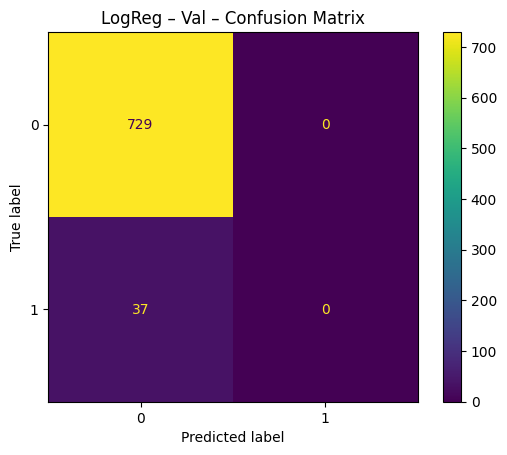

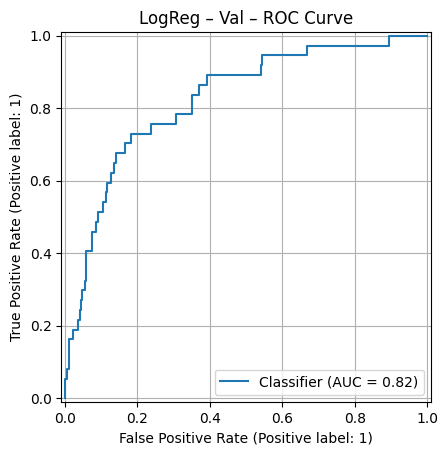

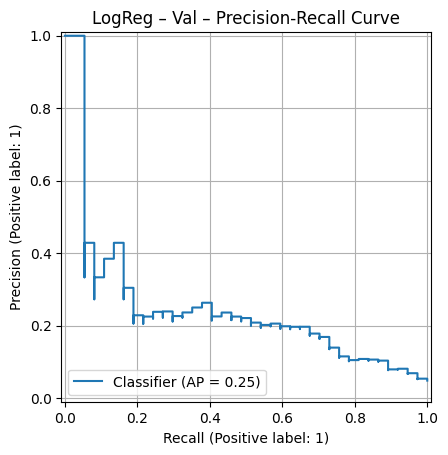


[Test] Classification report:
               precision    recall  f1-score   support

           0     0.9505    1.0000    0.9746       729
           1     0.0000    0.0000    0.0000        38

    accuracy                         0.9505       767
   macro avg     0.4752    0.5000    0.4873       767
weighted avg     0.9034    0.9505    0.9263       767



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


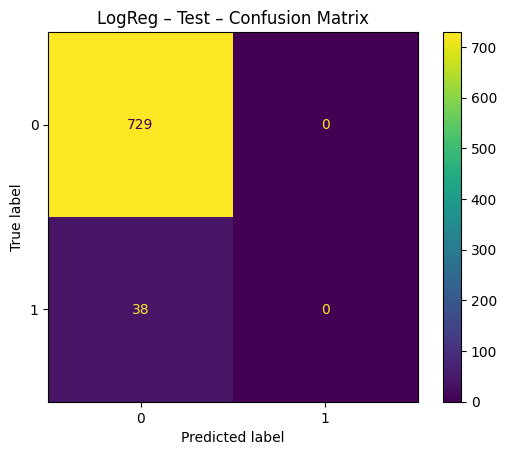

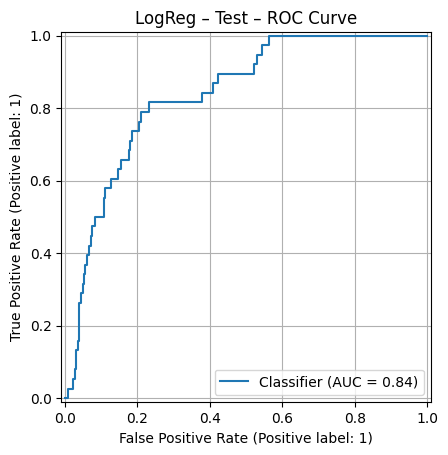

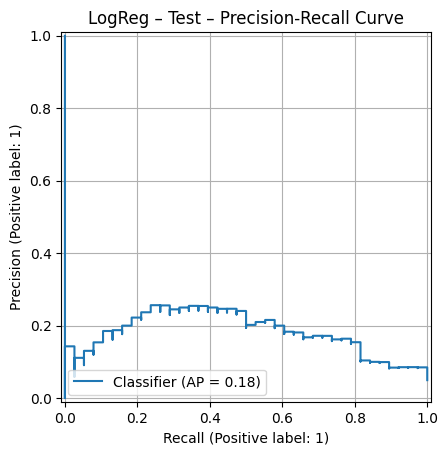


========== RandomForest ==========
Best params: {'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}

[Validation] Classification report:
               precision    recall  f1-score   support

           0     0.9529    0.9986    0.9752       729
           1     0.5000    0.0270    0.0513        37

    accuracy                         0.9517       766
   macro avg     0.7264    0.5128    0.5132       766
weighted avg     0.9310    0.9517    0.9306       766



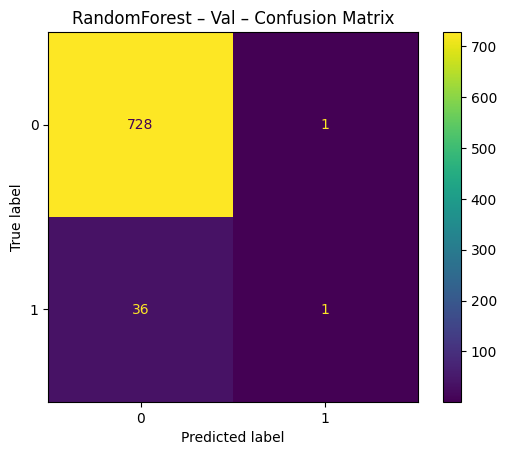

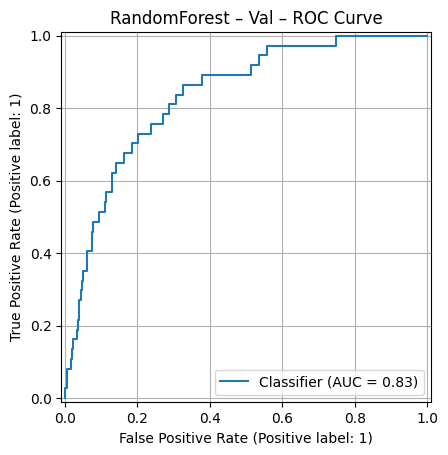

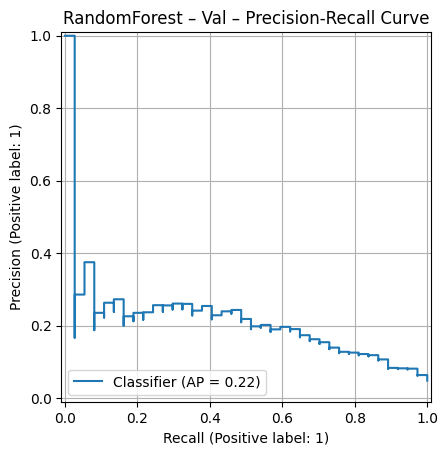


[Test] Classification report:
               precision    recall  f1-score   support

           0     0.9505    1.0000    0.9746       729
           1     0.0000    0.0000    0.0000        38

    accuracy                         0.9505       767
   macro avg     0.4752    0.5000    0.4873       767
weighted avg     0.9034    0.9505    0.9263       767



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


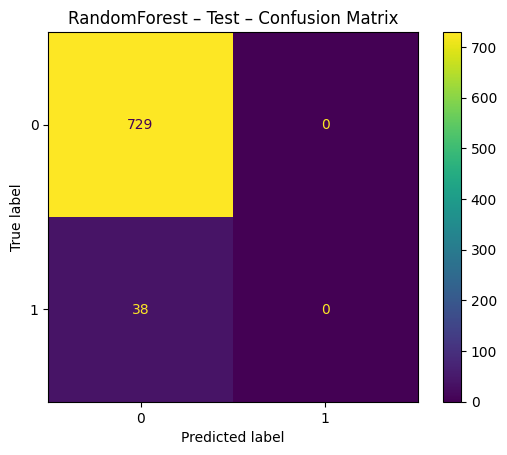

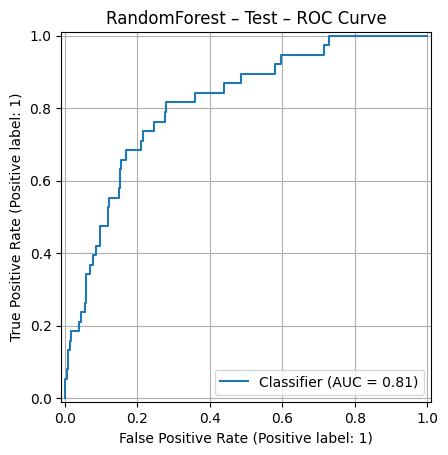

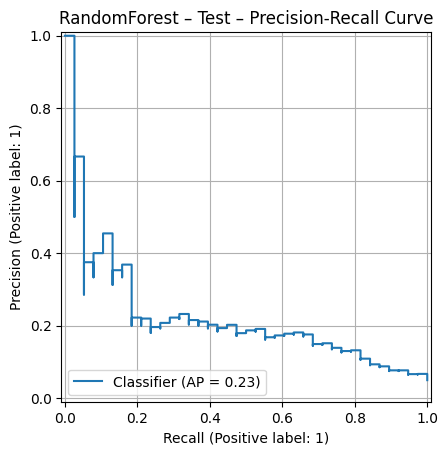


========== LightGBM ==========
[LightGBM] [Info] Number of positive: 174, number of negative: 3403
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 884
[LightGBM] [Info] Number of data points in the train set: 3577, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048644 -> initscore=-2.973357
[LightGBM] [Info] Start training from score -2.973357
Best params: {'clf__learning_rate': 0.05, 'clf__n_estimators': 100, 'clf__num_leaves': 31}

[Validation] Classification report:
               precision    recall  f1-score   support

           0     0.9527    0.9945    0.9732       729
           1     0.2000    0.0270    0.0476        37

    accuracy                         0.9478       766
   macro avg     0.5763    0.5108    0.5104       766
weighted avg     0.9163    0.9478    0.9284       766



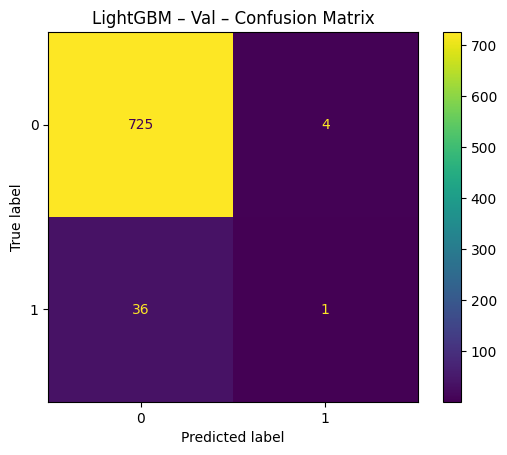

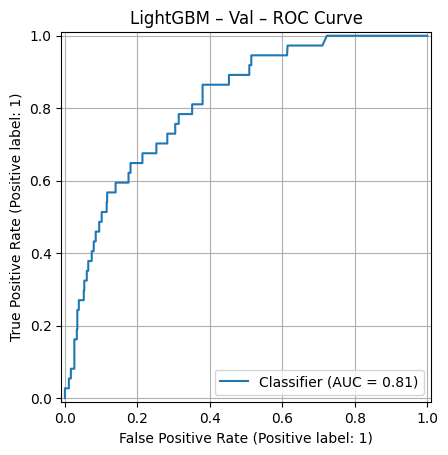

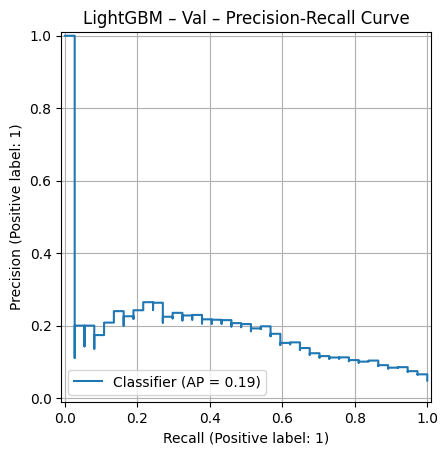


[Test] Classification report:
               precision    recall  f1-score   support

           0     0.9528    0.9973    0.9745       729
           1     0.5000    0.0526    0.0952        38

    accuracy                         0.9505       767
   macro avg     0.7264    0.5249    0.5349       767
weighted avg     0.9304    0.9505    0.9310       767



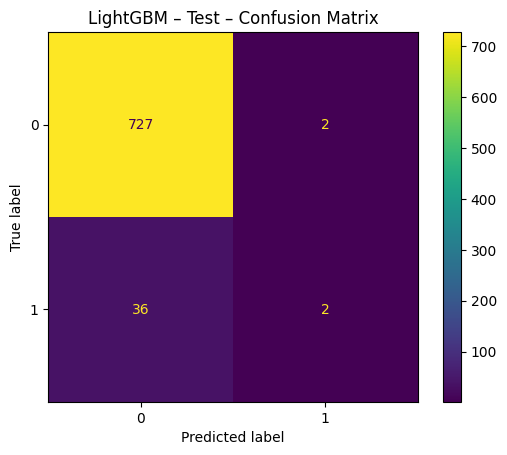

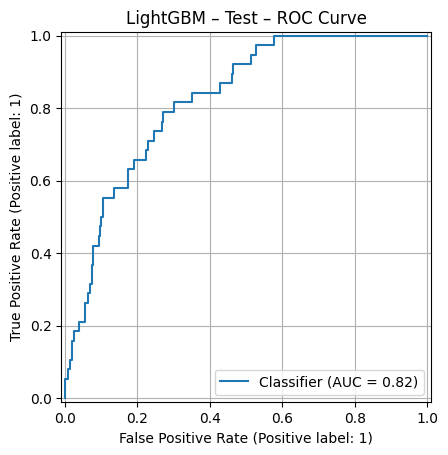

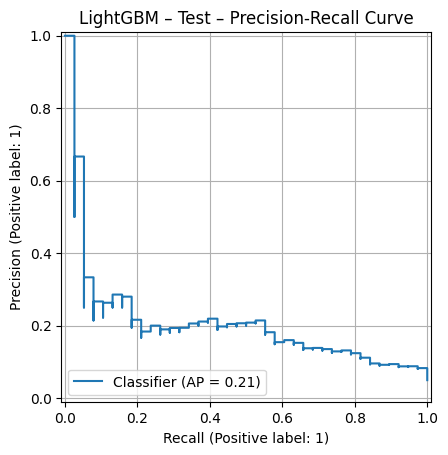

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier

#1. Utility functions
#-----------------------------

def evaluate(model, X, y, set_name: str):
    proba = model.predict_proba(X)[:, 1]
    preds = (proba >= 0.5).astype(int)
    print(f"\n[{set_name}] Classification report:\n", classification_report(y, preds, digits=4))
    return preds, proba

def plot_results(y_true, preds, proba, prefix: str):
    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_true, preds)
    plt.title(f"{prefix} – Confusion Matrix")
    plt.grid(False)
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_predictions(y_true, proba)
    plt.title(f"{prefix} – ROC Curve")
    plt.grid(True)
    plt.show()

    # Precision-Recall Curve
    PrecisionRecallDisplay.from_predictions(y_true, proba)
    plt.title(f"{prefix} – Precision-Recall Curve")
    plt.grid(True)
    plt.show()

#2. CV + parameter grids
#-----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}

# Logistic Regression
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="liblinear"))
])
param_lr = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l1", "l2"]
}

# Random Forest
pipe_rf = Pipeline([
    ("clf", RandomForestClassifier(random_state=42))
])
param_rf = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5]
}

# LightGBM
pipe_lgbm = Pipeline([
    ("clf", LGBMClassifier(random_state=42))
])
param_lgbm = {
    "clf__n_estimators": [100, 200],
    "clf__num_leaves": [31, 63],
    "clf__learning_rate": [0.05, 0.1]
}

models = {
    "LogReg": (pipe_lr, param_lr),
    "RandomForest": (pipe_rf, param_rf),
    "LightGBM": (pipe_lgbm, param_lgbm)
}

#3. Huấn luyện và đánh giá
#-----------------------------
for name, (pipe, param) in models.items():
    print("\n==========", name, "==========")
    grid = GridSearchCV(pipe, param_grid=param, cv=cv, scoring=scoring, refit="pr_auc", n_jobs=-1)
    grid.fit(X_train, y_train)
    print("Best params:", grid.best_params_)

    # Validation
    preds_val, proba_val = evaluate(grid, X_val, y_val, "Validation")
    plot_results(y_val, preds_val, proba_val, f"{name} – Val")

    # Test
    preds_test, proba_test = evaluate(grid, X_test, y_test, "Test")
    plot_results(y_test, preds_test, proba_test, f"{name} – Test")

**#ESEMBLE LEARNING**

**#Voting**

[LightGBM] [Info] Number of positive: 3403, number of negative: 3403
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000925 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1040
[LightGBM] [Info] Number of data points in the train set: 6806, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Validation set:
Accuracy: 0.9007832898172323
F1-score: 0.17391304347826086

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95       729
           1       0.15      0.22      0.17        37

    accuracy                           0.90       766
   macro avg       0.55      0.58      0.56       766
weighted avg       0.92      0.90      0.91       766



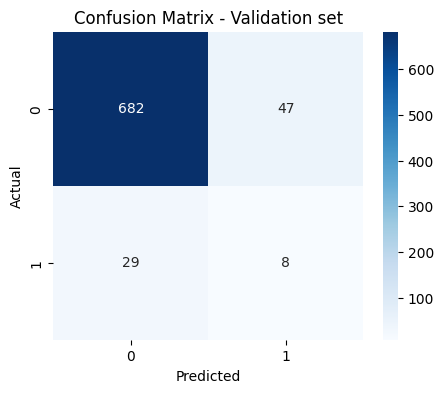


Test set:
Accuracy: 0.8970013037809648
F1-score: 0.16842105263157894

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.95       729
           1       0.14      0.21      0.17        38

    accuracy                           0.90       767
   macro avg       0.55      0.57      0.56       767
weighted avg       0.92      0.90      0.91       767



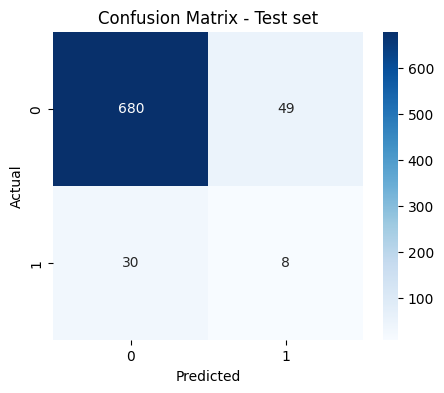

In [ ]:
from sklearn.ensemble import VotingClassifier
import lightgbm as lgb
# Logistic Regression với best params
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.1, penalty='l2', solver='liblinear'))
])

# Random Forest với best params
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

# LightGBM với best params
lgbm = lgb.LGBMClassifier(
    learning_rate=0.1,
    n_estimators=200,
    num_leaves=63,
    random_state=42
)

# Ensemble Voting
voting = VotingClassifier(
    estimators=[('logreg', logreg), ('rf', rf), ('lgbm', lgbm)],
    voting='soft'  # dùng xác suất trung bình
)

# Huấn luyện trên train
voting.fit(X_train_smote, y_train_smote)

# Đánh giá trên val và test
for name, X, y in [('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    y_pred = voting.predict(X)
    print(f"\n{name} set:")
    print("Accuracy:", accuracy_score(y, y_pred))
    print("F1-score:", f1_score(y, y_pred))
    print("\nClassification Report:\n", classification_report(y, y_pred))

    # Vẽ ma trận nhầm lẫn
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name} set")
    plt.show()


**#Stacking**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Validation set:
Accuracy: 0.8524804177545692
F1-score: 0.18705035971223022

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.88      0.92       729
           1       0.13      0.35      0.19        37

    accuracy                           0.85       766
   macro avg       0.55      0.61      0.55       766
weighted avg       0.92      0.85      0.88       766



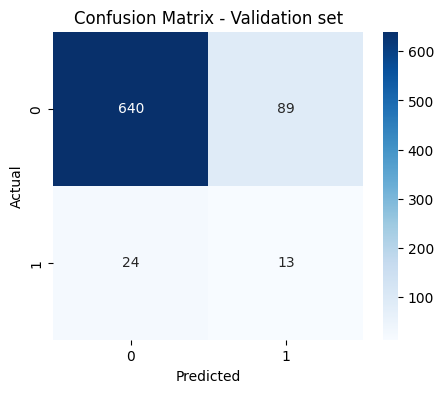


Test set:
Accuracy: 0.8578878748370273
F1-score: 0.15503875968992248

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.92       729
           1       0.11      0.26      0.16        38

    accuracy                           0.86       767
   macro avg       0.53      0.58      0.54       767
weighted avg       0.92      0.86      0.88       767



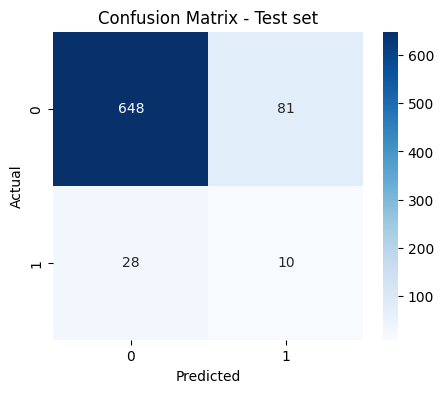

In [ ]:
from sklearn.ensemble import StackingClassifier
# ===== Base models với best params =====
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.1, penalty='l2', solver='liblinear'))
])

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

lgbm = lgb.LGBMClassifier(
    learning_rate=0.1,
    n_estimators=200,
    num_leaves=63,
    random_state=42
)

# ===== Stacking Classifier =====
stacking = StackingClassifier(
    estimators=[
        ('logreg', logreg),
        ('rf', rf),
        ('lgbm', lgbm)
    ],
    final_estimator=LogisticRegression(),  # mô hình meta
    cv=5,
    n_jobs=-1,
    passthrough=True  # giữ feature gốc cho meta-model
)

# ===== Huấn luyện trên train_smote =====
stacking.fit(X_train_smote, y_train_smote)

# ===== Đánh giá trên Validation và Test =====
for name, X, y in [('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    y_pred = stacking.predict(X)
    print(f"\n{name} set:")
    print("Accuracy:", accuracy_score(y, y_pred))
    print("F1-score:", f1_score(y, y_pred))
    print("\nClassification Report:\n", classification_report(y, y_pred))

    # Vẽ ma trận nhầm lẫn
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name} set")
    plt.show()


**###**